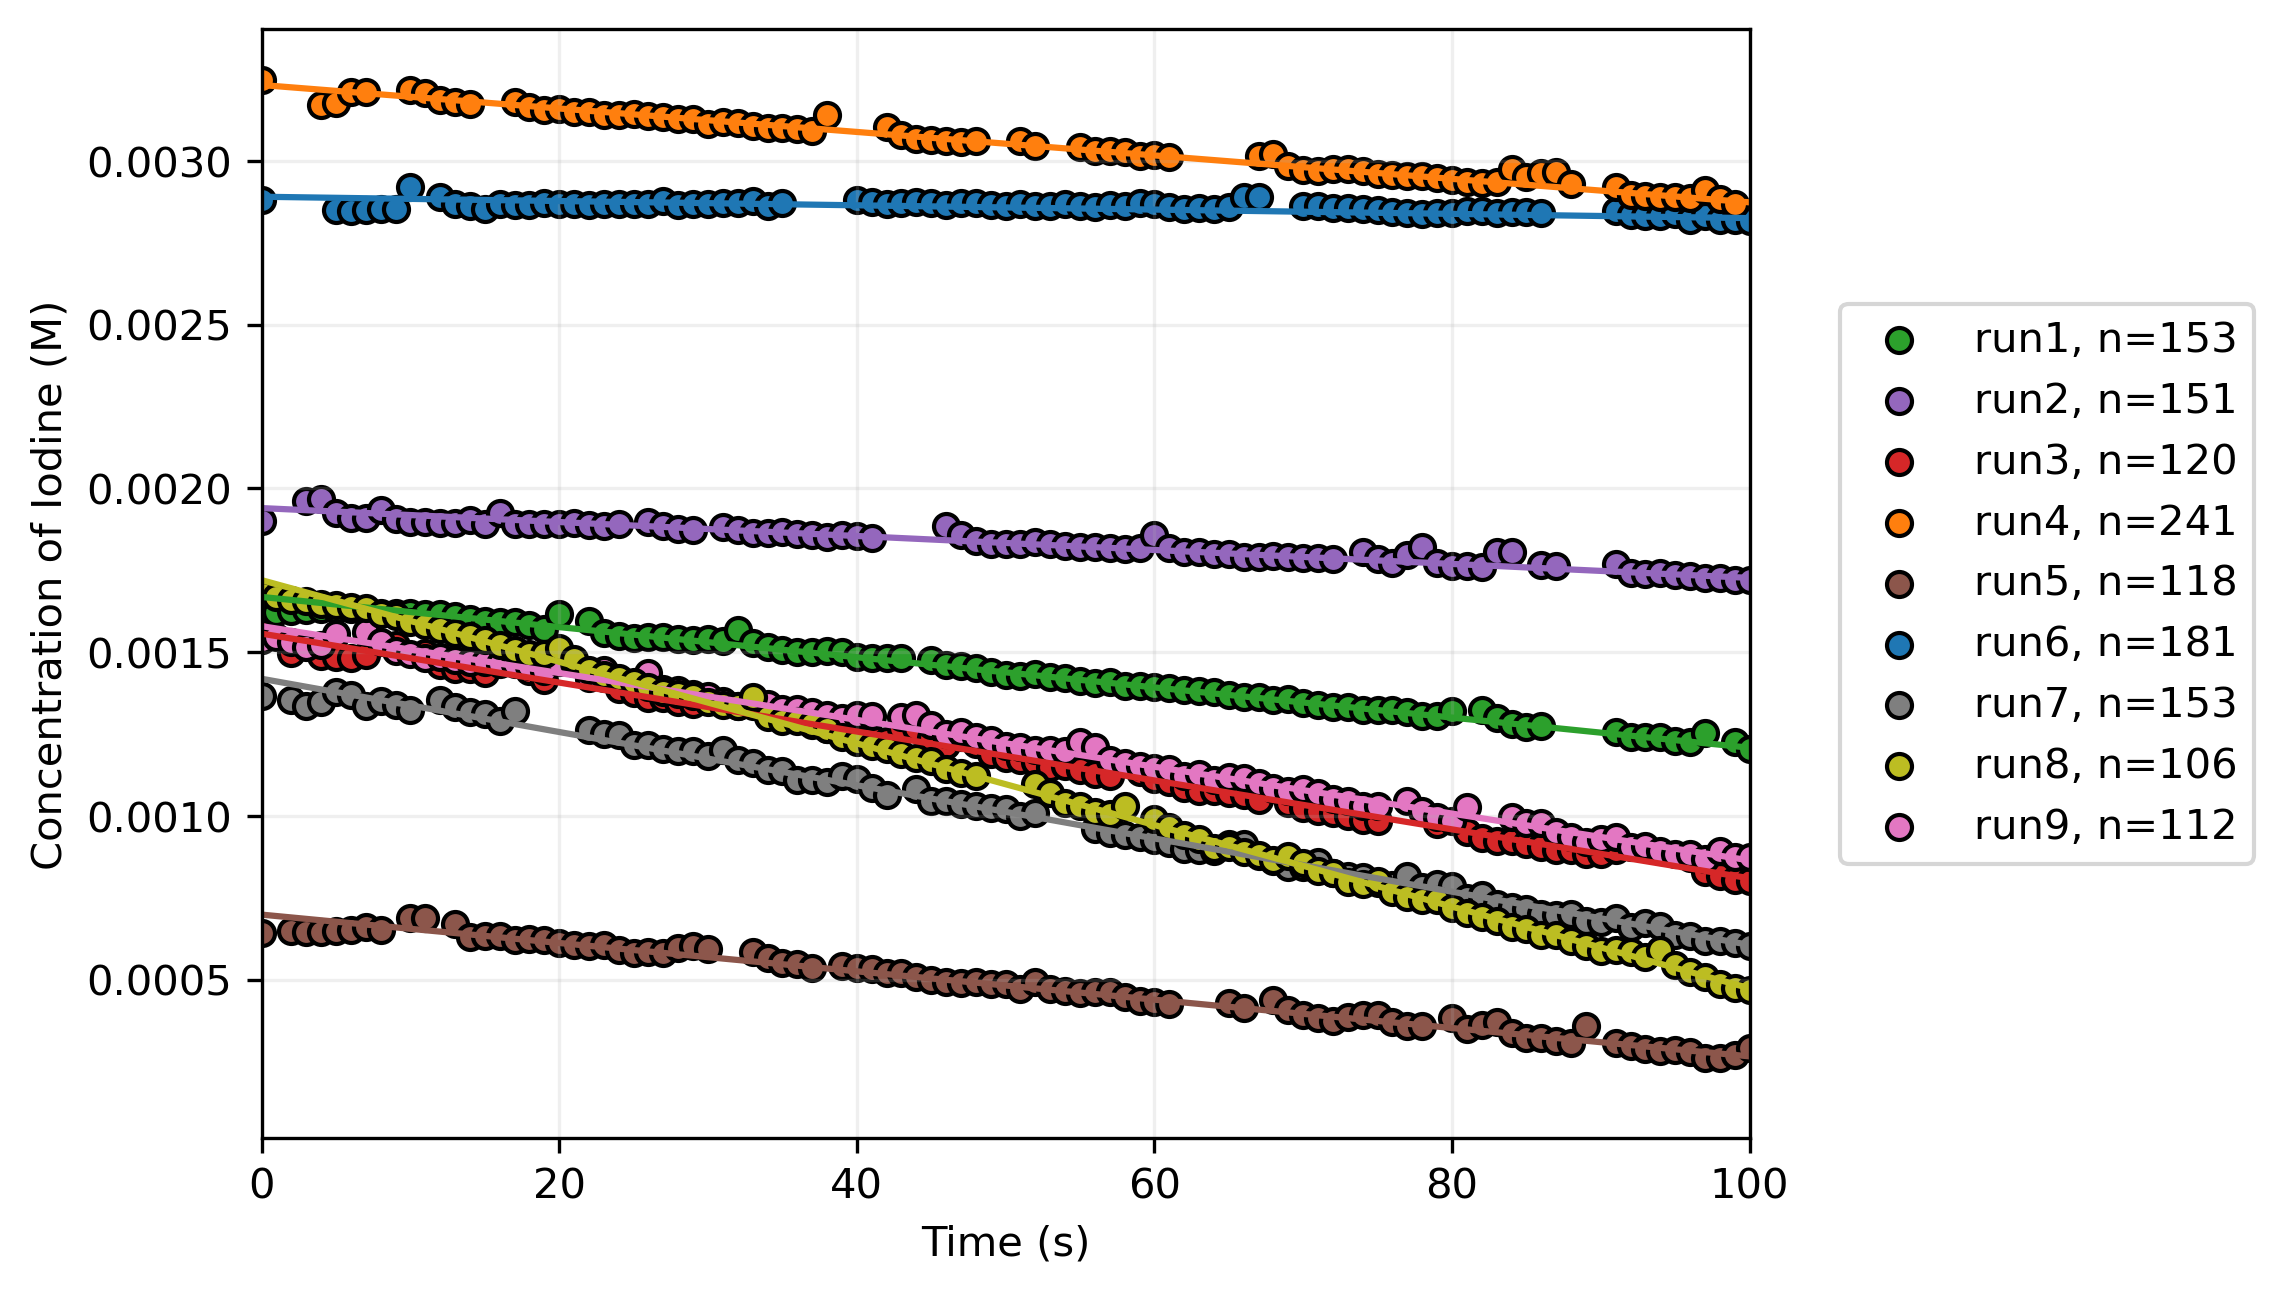

In [10]:
from glob import glob
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LinearRegression, RANSACRegressor

ransac = RANSACRegressor(
    estimator=LinearRegression(),
    residual_threshold=0.00005, loss='absolute_error', max_trials=10000  # adjust if needed,
)

fig,ax = plt.subplots(dpi=300)

names = []
rates = []
sigma_rates = []
for detector,m,b in zip(['absorbance_left', 'absorbance_right'], [101.4, 107.3], [0.02058, 0.02121]):
    signals = glob('*.csv', root_dir=detector)
    for signal in signals:
        names.append(signal)
        df = pd.read_csv(f'{detector}/{signal}')
        x = df["Data Set 1:Time(s)"].to_numpy()
        y = df["Data Set 1:Absorbance"].to_numpy()
        y = (y-b)/m
        
        X = x.reshape(-1,1)
        ransac.fit(X, y)
        rates.append({
            "slope": abs(float(ransac.estimator_.coef_[0])),
            "intercept": float(ransac.estimator_.intercept_),
        })

        inlier_mask = ransac.inlier_mask_
        outlier_mask = ~inlier_mask

        x_clean = x[inlier_mask]
        x_clean -= x_clean[0]
        y_clean = y[inlier_mask]
        coeffs, cov = np.polyfit(x_clean, y_clean, 1, cov=True)
        m_LR, b_LR = coeffs
        slope_err = np.sqrt(cov[0, 0])
        sigma_rates.append(slope_err)
        rates[-1]["slope_err"] = float(slope_err)

        plt.scatter(x_clean, y_clean, label=f'{signal[:4]}, n={max(x_clean)}', edgecolor='black')
        plt.plot(x_clean, m_LR*x_clean+b_LR)

handles, labels = ax.get_legend_handles_labels()
sorted_pairs = sorted(zip(labels, handles), key=lambda x: x[0])
ax.set(xlabel='Time (s)', ylabel='Concentration of Iodine (M)',
       xlim=(0,100)
       )

if sorted_pairs:
    sorted_labels, sorted_handles = zip(*sorted_pairs)
    ax.legend(sorted_handles, sorted_labels, bbox_to_anchor=(1.2, 0.5))
ax.grid(alpha=0.2)
fig.savefig('collecteddata.pdf', bbox_inches='tight')

In [11]:
rates

[{'slope': 6.530829607113096e-07,
  'intercept': 0.002893378439248779,
  'slope_err': 1.8330568356434113e-08},
 {'slope': 3.583184112238362e-06,
  'intercept': 0.0033645710026222087,
  'slope_err': 1.6097986198904623e-08},
 {'slope': 4.605152258115083e-06,
  'intercept': 0.001981780714659723,
  'slope_err': 2.6231982080341658e-08},
 {'slope': 7.471545432401667e-06,
  'intercept': 0.00195998635532803,
  'slope_err': 5.232965931351223e-08},
 {'slope': 2.1317286484586912e-06,
  'intercept': 0.0020295059889840466,
  'slope_err': 3.048486648957014e-08},
 {'slope': 4.3288481027202535e-06,
  'intercept': 0.000871609260824778,
  'slope_err': 4.5192723323037985e-08},
 {'slope': 7.154110620911688e-06,
  'intercept': 0.0019514112863690302,
  'slope_err': 5.3863115914858115e-08},
 {'slope': 8.127727816743724e-06,
  'intercept': 0.0017519223846413465,
  'slope_err': 3.162839751939222e-08},
 {'slope': 1.246372476436018e-05,
  'intercept': 0.0022433790381774527,
  'slope_err': 4.513216408112537e-08}]

In [12]:
df2 = pd.DataFrame(rates, index=names).sort_index()
df2, df2['slope_err'].sum()

(                             slope  intercept     slope_err
 run1_standard_30.csv  4.605152e-06   0.001982  2.623198e-08
 run2_hcl1_30.csv      2.131729e-06   0.002030  3.048487e-08
 run3_hcl2_30.csv      7.471545e-06   0.001960  5.232966e-08
 run4_iodine1_30.csv   3.583184e-06   0.003365  1.609799e-08
 run5_iodine2_30.csv   4.328848e-06   0.000872  4.519272e-08
 run6_acetone1_30.csv  6.530830e-07   0.002893  1.833057e-08
 run7_acetone2_30.csv  8.127728e-06   0.001752  3.162840e-08
 run8 40C.csv          1.246372e-05   0.002243  4.513216e-08
 run9 35C.csv          7.154111e-06   0.001951  5.386312e-08,
 3.1929146327717645e-07)

In [13]:
df2.to_clipboard(excel=True)

In [14]:
# temp_signals = glob('*.csv', root_dir='temperatures')
# names, temps, sigmatemps = [], [], []
# for temp in temp_signals:
#     df_TEMP = pd.read_csv(f'temperatures/{temp}', header=None)
#     names.append(temp)
#     temps.append(df_TEMP[2].mean())
#     sigmatemps.append(df_TEMP[2].std())

In [15]:
# df_exportTemps = pd.DataFrame({'avg temperature':temps, 'sigma temp':sigmatemps}, index=names).sort_index()
# df_exportTemps

In [16]:
# df_exportTemps.to_clipboard(excel=True)